Saving googl_data_2020_2025.csv to googl_data_2020_2025 (1).csv
                       Price    Adj Close        Close         High  \
0  2020-01-02 00:00:00+00:00  68.18682098  68.43399811  68.43399811   
1  2020-01-03 00:00:00+00:00  67.83010101   68.0759964      68.6875   
2  2020-01-06 00:00:00+00:00  69.63805389  69.89050293  69.91600037   
3  2020-01-07 00:00:00+00:00  69.50354767  69.75550079  70.17500305   
4  2020-01-08 00:00:00+00:00  69.99825287   70.2519989  70.59249878   

           Low         Open    Volume  
0  67.32450104  67.42050171  27278000  
1  67.36599731  67.40000153  23408000  
2  67.55000305  67.58149719  46768000  
3  69.57800293  70.02300262  34330000  
4  69.63150024  69.74099731  35314000  
Price         object
Adj Close     object
Close        float64
High          object
Low           object
Open          object
Volume        object
dtype: object
[[0.10925401]
 [0.10676708]
 [0.11937189]
 [0.11843407]
 [0.12188309]]
Index(['Price', 'Adj Close', 'Close',

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 0.0293
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0049
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0040
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0035
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0034
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0034
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0035
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0030
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0030
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0029
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0028
Epoch 12/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0033
Epoch 13/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0028
Epoch 14/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0027
Epoch 15/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0028
Epoch 16/20
38/

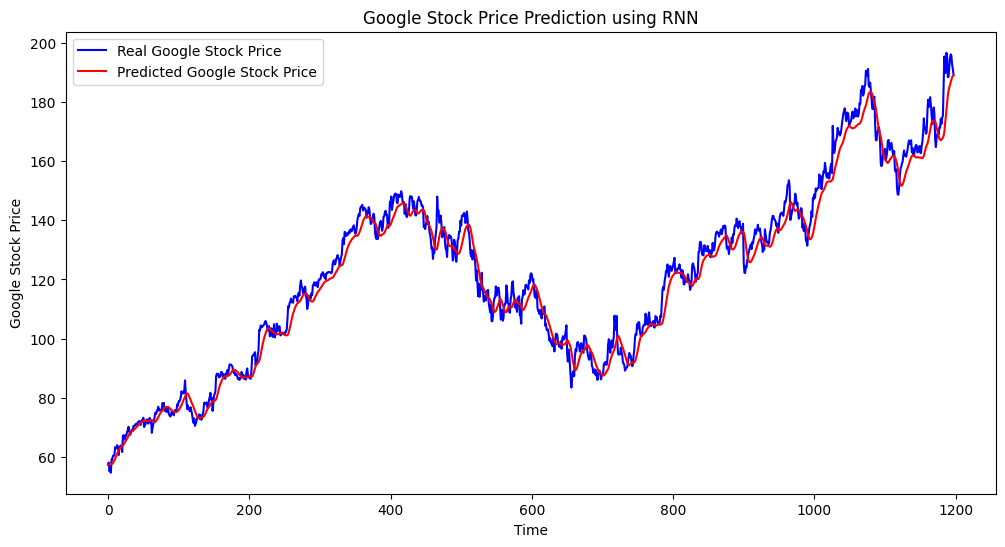

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

Predicted Next Day Google Stock Price:
188.77983


In [4]:
# ============================================
# Google Stock Price Prediction using RNN/LSTM
# Complete Google Colab Code
# ============================================

# Step 1: Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dropout

# ============================================
# Step 2: Load Dataset
# ============================================

# Replace filename if needed
from google.colab import files
uploaded = files.upload()

# ============================================
# Load Dataset Correctly
# ============================================

df = pd.read_csv('googl_data_2020_2025.csv')

# Remove first 2 unnecessary rows
df = df.iloc[2:]

# Reset index
df.reset_index(drop=True, inplace=True)

# Show dataset
print(df.head())

# ============================================
# Convert Close column to numeric
# ============================================

df['Close'] = pd.to_numeric(df['Close'])

# Check datatype
print(df.dtypes)

# ============================================
# Use Closing Price
# ============================================

data = df['Close'].values

# Convert to 2D array
data = data.reshape(-1,1)

# ============================================
# Feature Scaling
# ============================================

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

print(scaled_data[:5])
# ============================================
# Step 3: Check Columns
# ============================================

print(df.columns)

# ============================================
# Step 4: Use Closing Price
# ============================================

# Change column name if your dataset uses different name

data = df['Close'].values

# Convert to 2D array
data = data.reshape(-1,1)

# ============================================
# Step 5: Feature Scaling
# ============================================

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

# ============================================
# Step 6: Create Training Data
# ============================================

X = []
y = []

# Using previous 60 days to predict next day

for i in range(60, len(scaled_data)):

    X.append(scaled_data[i-60:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

# Reshape for LSTM

X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print("X Shape:", X.shape)
print("Y Shape:", y.shape)

# ============================================
# Step 7: Build RNN/LSTM Model
# ============================================

model = Sequential()

# First LSTM Layer
model.add(LSTM(
    units=50,
    return_sequences=True,
    input_shape=(X.shape[1],1)
))

model.add(Dropout(0.2))

# Second LSTM Layer
model.add(LSTM(
    units=50,
    return_sequences=False
))

model.add(Dropout(0.2))

# Output Layer
model.add(Dense(units=1))

# ============================================
# Step 8: Compile Model
# ============================================

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# ============================================
# Step 9: Train Model
# ============================================

history = model.fit(
    X,
    y,
    epochs=20,
    batch_size=32
)

# ============================================
# Step 10: Predict Prices
# ============================================

predicted_prices = model.predict(X)

# Convert back to original prices

predicted_prices = scaler.inverse_transform(predicted_prices)

real_prices = scaler.inverse_transform(y.reshape(-1,1))

# ============================================
# Step 11: Plot Results
# ============================================

plt.figure(figsize=(12,6))

plt.plot(real_prices, color='blue', label='Real Google Stock Price')

plt.plot(predicted_prices,
         color='red',
         label='Predicted Google Stock Price')

plt.title('Google Stock Price Prediction using RNN')

plt.xlabel('Time')

plt.ylabel('Google Stock Price')

plt.legend()

plt.show()

# ============================================
# Step 12: Predict Next Day Price
# ============================================

last_60_days = scaled_data[-60:]

X_test = []
X_test.append(last_60_days)

X_test = np.array(X_test)

X_test = np.reshape(X_test,
                    (X_test.shape[0],
                     X_test.shape[1],
                     1))

next_day_price = model.predict(X_test)

next_day_price = scaler.inverse_transform(next_day_price)

print("\nPredicted Next Day Google Stock Price:")

print(next_day_price[0][0])